In [ ]:
# --- IMPORT STATEMENTS ---

import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
from scipy.odr import ODR, RealData, Model, Data
from scipy.stats import spearmanr
from scipy import constants
from scipy.optimize import curve_fit

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

# masking code
from photutils.detection import DAOStarFinder
import healpy as hp

In [509]:
# --- GLOBAL VARIABLES ---
SAVE_FIGS = False

L_BOUNDS = [16, 32] # degrees
B_BOUNDS = [-1.1, 1.1] # degrees

SMOOTHING_FWHM = 5 # arcmin
REBIN_FACTOR = 5

LINUX_DIRECTORY = '/home/aimee/mphys' # Aimee
MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/maps'
MASKED_MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/masked_maps'
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures'

# MAPS

COMAP_MAPS = {
    "COMAP 26.5 GHz": "comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 27.5 GHz": "comap_160625_band01_band01_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 28.5 GHz": "comap_160625_band02_band02_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 29.5 GHz": "comap_160625_band03_band03_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 30.5 GHz": "comap_160625_band04_band04_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 31.5 GHz": "comap_160625_band05_band05_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 32.5 GHz": "comap_160625_band06_band06_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 33.5 GHz": "comap_160625_band07_band07_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits"
}
COMAP_KEYS = list(COMAP_MAPS.keys())
COMAP_FREQS = {
    "COMAP 26.5 GHz": 26.5,
    "COMAP 27.5 GHz": 27.5,
    "COMAP 28.5 GHz": 28.5,
    "COMAP 29.5 GHz": 29.5,
    "COMAP 30.5 GHz": 30.5,
    "COMAP 31.5 GHz": 31.5,
    "COMAP 32.5 GHz": 32.5,
    "COMAP 33.5 GHz": 33.5
}


EFFELSBERG_MAPS = { # User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
    "Effelsberg 1.43 GHz (10')":"EFFELSBERG-1.4285714285714286GHz-10.0amin.fits",
    "Effelsberg 1.43 GHz (15')":"EFFELSBERG-1.4285714285714286GHz-15.0amin.fits",
    "Effelsberg 1.43 GHz (20')":"EFFELSBERG-1.4285714285714286GHz-20.0amin.fits",
    "Effelsberg 1.43 GHz (25')":"EFFELSBERG-1.4285714285714286GHz-25.0amin.fits",
    "Effelsberg 1.43 GHz (30')":"EFFELSBERG-1.4285714285714286GHz-30.0amin.fits",
    "Effelsberg 1.43 GHz (60')":"EFFELSBERG-1.4285714285714286GHz-60.0amin.fits",
    "Effelsberg 2.73 GHz (5')":"EFFELSBERG-2.7272727272727275GHz-5.0amin.fits",
    "Effelsberg 2.73 GHz (10')":"EFFELSBERG-2.7272727272727275GHz-10.0amin.fits",
    "Effelsberg 2.73 GHz (15')":"EFFELSBERG-2.7272727272727275GHz-15.0amin.fits",
    "Effelsberg 2.73 GHz (20')":"EFFELSBERG-2.7272727272727275GHz-20.0amin.fits",
    "Effelsberg 2.73 GHz (25')":"EFFELSBERG-2.7272727272727275GHz-25.0amin.fits",
    "Effelsberg 2.73 GHz (30')":"EFFELSBERG-2.7272727272727275GHz-30.0amin.fits",
    "Effelsberg 2.73 GHz (60')":"EFFELSBERG-2.7272727272727275GHz-60.0amin.fits"
}
EFFELSBERG_KEYS = list(EFFELSBERG_MAPS.keys())


In [510]:
# --- FUNCTION DEFINITIONS ---

In [511]:
def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
        
    return data, header, wcs

In [512]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -0.01 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [513]:
def cut_data(data, wcs, header):
    
    lat_min = B_BOUNDS[0]
    lat_max = B_BOUNDS[1]
    long_min = L_BOUNDS[0]
    long_max = L_BOUNDS[1]
    step = header['CDELT2']  # pixel resolution

    # may be off by fraction of pixel
    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row

    header['CRPIX1'] = wcs.wcs.crpix[0]
    header['CRPIX2'] = wcs.wcs.crpix[1]
    
    return submap, wcs, header

In [514]:
def sigma(FWHM1, FWHM2, scale):
    return np.sqrt(abs(FWHM1**2 - FWHM2**2)) /\
        (2*np.sqrt(2 * np.log(2)) * scale)

In [515]:
def rebin_array(data, factor):
    n_rows, n_cols = data.shape
    # print(f"Original shape: {data.shape}")

    # Crop rows and columns if not divisible by factor
    if n_rows % factor != 0:
        new_n_rows = (n_rows // factor) * factor
        data = data[:new_n_rows, :]
        # print(f"Adjusted rows to: {new_n_rows}")
    if n_cols % factor != 0:
        new_n_cols = (n_cols // factor) * factor
        data = data[:, :new_n_cols]
        # print(f"Adjusted columns to: {new_n_cols}")

    # Reshape and average in blocks of factor x factor
    reshaped_data = data.reshape(data.shape[0] // factor, factor, data.shape[1] // factor, factor)
    rebinned_data = reshaped_data.mean(axis=(1, 3))  # If any pixel in block is nan, whole block is nan (good)
    # print(f"Re-shaped data to: {rebinned_data.shape}")
    
    return rebinned_data


def rebin_map(data, wcs, header, factor):
    
    l_min = L_BOUNDS[0]
    l_max = L_BOUNDS[1]
    b_min = B_BOUNDS[0]
    b_max = B_BOUNDS[1]
    step = wcs.wcs.cdelt[1] # pixel size in degrees

    data = rebin_array(data, factor)

    ny, nx = data.shape
    cy, cx = ny // 2, nx // 2
    # print(cy, cx)   

    # Indices for cutout
    wcs.wcs.crpix[0] = cx
    wcs.wcs.crpix[1] = cy
    wcs.wcs.cdelt[0] = -step * factor
    wcs.wcs.cdelt[1] = step * factor
    wcs.wcs.crval[0] = (l_min + l_max) / 2
    wcs.wcs.crval[1] = (b_min + b_max) / 2

    header = wcs.to_header()

    return data, wcs, header

In [516]:
def JyPersr_to_K(inp, freq):
    
    k_B = constants.Boltzmann
    c = constants.speed_of_light

    factor = (c**2)/(2*k_B*(freq**2)*10**(26))
    
    return factor*inp

In [517]:
def weighted_mean(values, weights):
    values = np.array(values)
    weights = np.array(weights)
    weighted_sum = np.sum(weights*values)
    # print(weighted_sum)
    normalisation = np.sum(weights)
    # print(normalisation)
    return weighted_sum/normalisation, np.sqrt(1/normalisation)


def unpack2D(arr):
    unpacked = []
    for i, row in enumerate(arr):
        unpacked = np.append(unpacked,row)
    return unpacked


def linreg_model(x, m, c):
    return m*x + c


def linreg_model_odr(params, x):
    m = params[0]
    c = params[1]
    return m*x + c


def tt_scatter_odr(datax, datay, datax_unc, datay_unc):
    c_initial = min(datay)
    y_diff = (max(datay) - min(datay)) / (datax[np.argmax(datay)] - datax[np.argmin(datay)])
    x_diff = (datay[np.argmax(datax)] - datay[np.argmin(datax)]) / (max(datax) - min(datax))
    m_initial = (y_diff + x_diff) / 2
    
    # Setup odr
    linreg = Model(linreg_model_odr)
    data = Data(datax, datay, we=(1/(datax_unc**2)), wd=(1/(datay_unc**2)))
    odrobj = ODR(data, linreg, beta0=(m_initial, c_initial))
    odrout = odrobj.run()
    odrbeta = odrout.beta
    odrsdbeta = odrout.sd_beta

    return [odrbeta[0], odrsdbeta[0]], [odrbeta[1], odrsdbeta[1]]

In [518]:
def full_TT_plot(x, y, x_model, y_model, xlabel='x', ylabel='y', title='title'):
    
    plt.scatter(x, y, label='data')
    plt.plot(x_model, y_model, label='model', color='r')
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

In [519]:
def gradient_to_beta(gradient, gradient_err, freq1, freq2):
        
    m_to_beta = (-1) / np.log(freq2 / freq1) 

    beta = np.log(gradient) * m_to_beta
    beta_err = np.abs(gradient_err / gradient * m_to_beta)

    return beta, beta_err
    

# def beta_to_gradient(beta, beta_err, freq1, freq2): # incorrect? # use to get initial estimate for gradient for fitting
    
#     beta_to_m = -np.log(freq2 / freq1)

#     grad = np.exp(beta * beta_to_m)
#     grad_err = np.abs(beta_err * beta_to_m * grad)

#     return grad, grad_err

# # DEBUG
# f1 = 26.5
# f2 = 2.73
# beta = -2.1
# beta_err = 0.01

# print(beta, beta_err)
# grad, grad_err = beta_to_gradient(beta, beta_err, f1, f2)
# print(grad, grad_err)
# beta, beta_err = beta_to_gradient(grad, grad_err, f1, f2)
# print(beta, beta_err)

In [ ]:
# NEED TO DEBUG / SPLIT UP THESE FUNCTIONS

def incr_TTres(x_axis_map, y_axis_map, x_axis_uncs, y_axis_uncs,
               x_freq, y_freq, show_plot=False, save_plot=True,
               plot_title="Title", plot_savedir="plot.png", return_raw=False):
    
    full_lonvals = np.linspace(L_BOUNDS[1], L_BOUNDS[0], len(y_axis_map[0,:]))

    m_results = []
    m_uncs = []
    c_results = []
    c_uncs = []
    for i, col in enumerate(np.rot90(x_axis_map)):
        if len(col) > 2:
            y_col, y_unc = y_axis_map[:,i], y_axis_uncs[:,i]
            x_unc = x_axis_uncs[:,i]
                    
            # m_result, c_result = tt_scatter(col, y_col, y_unc)
            m_result, c_result = tt_scatter_odr(col, y_col, x_unc, y_unc)
            m_results.append(m_result[0])
            m_uncs.append(m_result[1])
            c_results.append(c_result[0])
            c_uncs.append(c_result[1])
        else:
            m_results.append(np.nan)
            m_uncs.append(np.nan)
            c_results.append(np.nan)
            c_uncs.append(np.nan)

    m_to_beta = -1/np.log(y_freq/x_freq)

    beta_results = np.array(np.log(np.array(m_results)) * m_to_beta)
    beta_uncs = np.abs(np.array(m_uncs)/m_results * m_to_beta)
    c_results = np.array(c_results)
    c_uncs = np.array(c_uncs)


    nanless_betares = []
    nanless_betauncs = []
    for i, val in enumerate(beta_results):
        if (not np.isnan(val) and
            not np.isinf(val) and
            not np.isnan(beta_uncs[i]) and
            not np.isinf(beta_uncs[i])):
            nanless_betares.append(val)
            nanless_betauncs.append(beta_uncs[i])


    nanless_cres = []
    nanless_cuncs = []
    for val in c_results:
        if (not np.isnan(val) and
            not np.isinf(val) and
            not np.isnan(c_uncs[i]) and
            not np.isinf(c_uncs[i])):
            nanless_cres.append(val)
            nanless_cuncs.append(c_uncs[i])


    beta_weights = 1/(beta_uncs**2)
    mean_beta, meanbeta_unc = weighted_mean(nanless_betares, nanless_betauncs)
    c_weights = 1/(c_uncs**2)
    mean_c, meanc_unc = weighted_mean(nanless_cres, nanless_cuncs)
    print(f"Mean spectral index = {mean_beta: .4f} +/- {meanbeta_unc: .4f}")
    print(f"Mean intercept = {mean_c: .4f} +/- {meanc_unc: .4f}")

    if show_plot:
        plt.plot(full_lonvals, beta_results)
        plt.plot([L_BOUNDS[0],L_BOUNDS[1]], [mean_beta, mean_beta], color='red')
        plt.title(plot_title)
        plt.ylabel("spectral index")
        plt.xlabel("l [deg]")
        if save_plot:
            plt.savefig(f"{plot_savedir}_betas.png", dpi=300)
        plt.show()

        plt.plot(full_lonvals, c_results)
        plt.plot([L_BOUNDS[0],L_BOUNDS[1]], [mean_c, mean_c], color='red')
        plt.title(f"incremental TT plot intercept results for l={L_BOUNDS[0]}_to_{L_BOUNDS[1]}")
        plt.ylabel("TT y-intercept [mK]")
        plt.xlabel("l [deg]")
        if save_plot:
            plt.savefig(f"{plot_savedir}_intercepts.png", dpi=300)
        plt.show()

    if return_raw:
        return m_results, m_uncs, c_results, c_uncs
    else:
        return beta_results, beta_uncs, c_results, c_uncs


# Iterating over square regions
def TTplot_lattice(x_axis_map, y_axis_map, x_axis_uncs, y_axis_uncs,
                   x_axis_wcs, y_axis_wcs, region_size, l_limits,
                   b_limits, freq_x, freq_y, figure_title= "Title",
                   save_plot=False, fig_savedir="lattice_plot.png"):
    
    b_min = b_limits[0]
    b_max = b_limits[1]
    l_min = l_limits[0]
    l_max = l_limits[1]

    bmin_array = []
    for i in range(0, int(np.floor((b_max-b_min)/region_size))):
        bmin_array.append(b_min + i*region_size)
    bmin_array = np.flip(bmin_array)

    lmin_array = []
    for i in range(0, int(np.floor((l_max-l_min)/region_size))):
        lmin_array.append(l_min + i*region_size)
    lmin_array = np.flip(lmin_array)


    fig, axs = plt.subplots(nrows=len(bmin_array), ncols=len(lmin_array),
                            figsize=(2.5*len(lmin_array), 2.5*len(bmin_array)),
                            dpi=300)


    betas = []
    beta_uncs = []
    intercepts = []
    intercept_uncs = []

    m_to_beta = -1/np.log(freq_y/freq_x)

    for i, bmin in enumerate(bmin_array):
        bmax = bmin + region_size
        for j, lmin in enumerate(lmin_array):
            print(lmin)
            lmax = lmin + region_size
            print(lmax)
            map1_cut, hdump, cut1_wcs = cutout_map(
                x_axis_map, x_axis_wcs,
                l_bounds = (lmin, lmax),
                b_bounds = (bmin, bmax)
                )
            map1_unc, hdump, wcsdump = cutout_map(
                x_axis_uncs, x_axis_wcs,
                l_bounds = (lmin, lmax),
                b_bounds = (bmin, bmax)
            )
            map1_unc = abs(map1_unc)

            map2_cut, hdump, cut2_wcs = cutout_map(
                y_axis_map, y_axis_wcs,
                l_bounds = (lmin, lmax),
                b_bounds = (bmin, bmax)
                )
            map2_unc, hdump, wcsdump = cutout_map(
                y_axis_uncs, y_axis_wcs,
                l_bounds = (lmin, lmax),
                b_bounds = (bmin, bmax)
            )
            map2_unc = abs(map2_unc)

            data_1 = np.array(unpack2D(map1_cut))
            dataunc_1 = np.array(unpack2D(map1_unc))
            data_2 = np.array(unpack2D(map2_cut))
            dataunc_2 = np.array(unpack2D(map2_unc))

            try:
                # m_res, c_res = tt_scatter(data_1, data_2, dataunc_2)
                m_res, c_res = tt_scatter_odr(data_1, data_2, dataunc_1, dataunc_2)
                beta_res = np.log(m_res[0]) * m_to_beta
                beta_unc = np.abs(m_res[1]/m_res[0] * m_to_beta)
                print(f"""
                Results for ({lmin}, {bmin}) - ({lmax}, {bmax}):
                Slope = {m_res[0]: .4f} +/- {m_res[1]: .4f}
                Intercept = {c_res[0]: .4f} +/- {c_res[1]: .4f}
                """)
                # if m_res[0] > 0:
                #     betas.append(beta_res)
                #     beta_uncs.append(beta_unc)
                omit_plot = False
                intercepts.append(c_res[0])
                intercept_uncs.append(c_res[1])
            except Exception as E:
                print(f"Could not generate TT plot for (l_min, b_min) -> (l_max, b_max)\n Reason: {E}")
                omit_plot = True

            # plot TT plot
            if not omit_plot:
                x_mod = np.linspace(0, np.max(data_1), 1000)
                y_mod = linreg_model(x_mod, m_res[0], c_res[0])
                if len(bmin_array) > 1:
                    ax = axs[i,j]
                else:
                    ax = axs[j]
                if len(bmin_array) > 1:
                    axs[-1,j].set_xlabel(f"{lmax} -> {lmin}")
                else:
                    ax.set_xlabel(f"{lmax} -> {lmin}")
                ax.errorbar(data_1, data_2, dataunc_2, dataunc_1,
                            linewidth=0, fmt='.')
                ax.plot(x_mod, y_mod, label=f"{beta_res: .2f} +/- {beta_unc: .2f}")

                ax.legend()
        if len(bmin_array) > 1:
            axs[i,0].set_ylabel(f"{bmin} -> {bmax}")
        else:
            axs[0].set_ylabel(f"{bmin} -> {bmax}")


    fig.suptitle(figure_title)
    fig.tight_layout()

    # figname = f"{comap_names[comap_index]}_vs_eberg_2.73_GHz_{lmin}_{bmin}_to_{lmax}_{bmax}_{region_size}_simple_mask.png"
    if save_plot:
        plt.savefig(fig_savedir, dpi=300)
    plt.show()

Getting data from /home/aimee/mphys/data/masked_maps/EFFELSBERG-2.7272727272727275GHz-5.0amin_masked.fits
Getting data from /home/aimee/mphys/data/masked_maps/comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19_masked.fits

Gradient = 0.0052016908290169325 +- 0.00032673082295450756
Intercept = 16.205897766373432 +- 0.25540477570664816

Beta = 2.3137415388528573 +- 0.027636058933409695


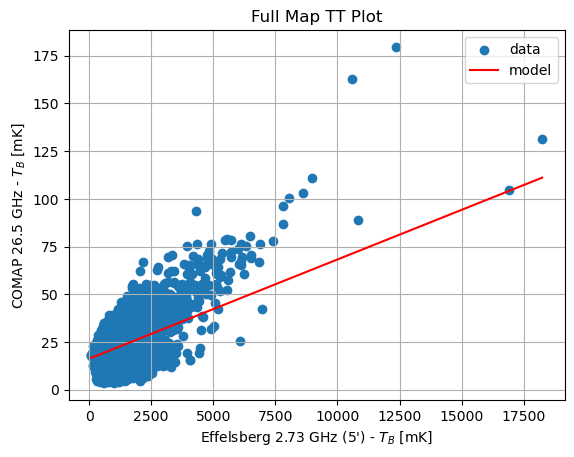

Mean spectral index =  nan +/-  inf
Mean intercept =  nan +/-  inf


/tmp/ipykernel_50958/2194853924.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return weighted_sum/normalisation, np.sqrt(1/normalisation)
/tmp/ipykernel_50958/2194853924.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  return weighted_sum/normalisation, np.sqrt(1/normalisation)
/tmp/ipykernel_50958/1964814364.py:60: RuntimeWarning: divide by zero encountered in divide
  c_weights = 1/(c_uncs**2)


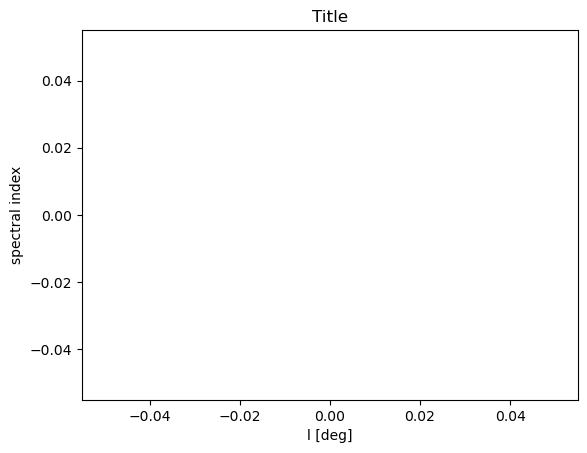

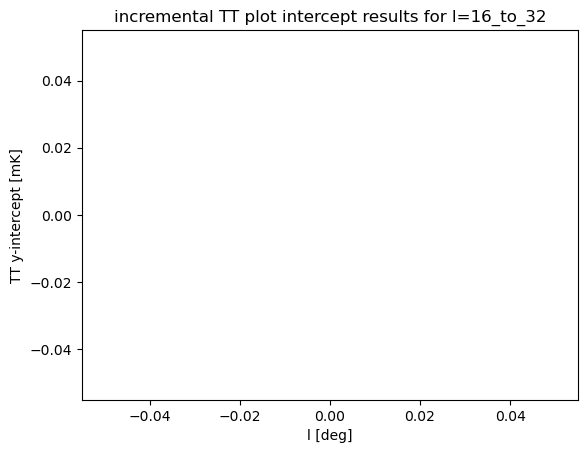

31.0
32.0


NameError: name 'cutout_map' is not defined

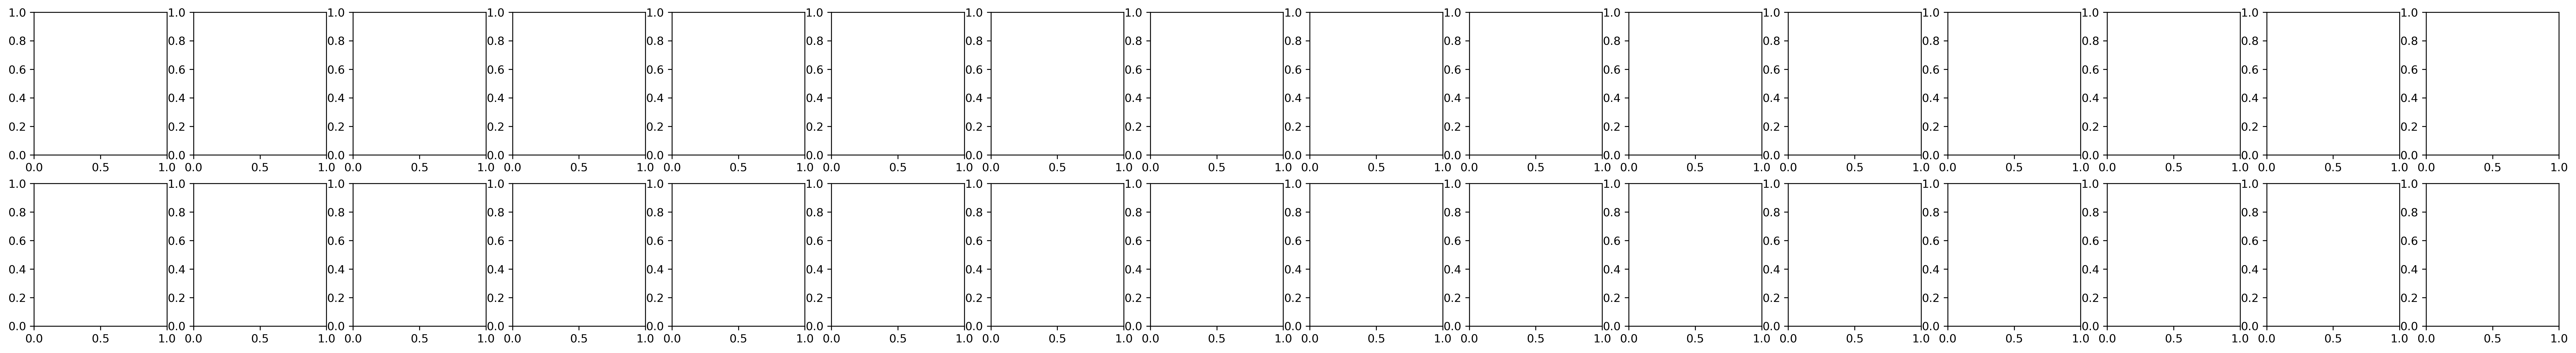

In [521]:
# --- MAIN CODE ---

comap_fwhm = 4.5
effelsberg_fwhm = 4.3
gdigs_fwhm = 0

comap_err = 0.05
effelsberg_err = 0.1
gdigs_err = 0.1 # TEMP - CHECK!

# TEMP - loop over pairs of maps later (and auto assign fwhm, error, etc.)
map1_title = "Effelsberg 2.73 GHz (5')"
map1_fname = EFFELSBERG_MAPS[map1_title]
map1_fwhm = effelsberg_fwhm
map1_err = effelsberg_err
map1_freq = 2.73e9 # Hz

map2_title = "COMAP 26.5 GHz"
map2_fname = COMAP_MAPS[map2_title]
map2_fwhm = comap_fwhm
map2_err = comap_err
map2_freq = 26.5e9 # Hz

# # Load in raw maps
# map1, header1, wcs1 = get_map(f'{MAPS_DIRECTORY}/{map1_fname}')
# # plot_fits(map1, wcs1, title=f'{map1_title} - original')
# map2, header2, wcs2 = get_map(f'{MAPS_DIRECTORY}/{map2_fname}')
# # plot_fits(map2, wcs2, title=f'{map2_title} - original')

# OR: Load in masked maps
map1, header1, wcs1 = get_map(f'{MASKED_MAPS_DIRECTORY}/{map1_fname.replace(".fits", "")}_masked.fits')
# plot_fits(map1, wcs1, title=f'{map1_title} - masked')
map2, header2, wcs2 = get_map(f'{MASKED_MAPS_DIRECTORY}/{map2_fname.replace(".fits", "")}_masked.fits')
# plot_fits(map2, wcs2, title=f'{map2_title} - masked')

# Convert to brigtness temperature [mK] (HARD CODED)
map1 = JyPersr_to_K(np.array(map1), map1_freq) # Jy/sr to K
map1 = np.array(map1) * 1000 # K to mK
map2 = np.array(map2) * 1000 # K to mK for COMAP 

# Mask values < 0
threshold = 0 # mK
map1[np.where(map1 <= threshold)] = np.nan
map2[np.where(map2 <= threshold)] = np.nan

# Cut data to size
map1, wcs1, header1 = cut_data(map1, wcs1, header1)
# plot_fits(map1, wcs1, title=f'{map1_title} - cut')
map2, wcs2, header2 = cut_data(map2, wcs2, header2)
# plot_fits(map2, wcs2, title=f'{map2_title} - cut')

# Smooth to 5 arcmin (doesn't change wcs/header)
smoothing_kernel1 = Gaussian2DKernel(x_stddev=sigma(map1_fwhm, SMOOTHING_FWHM, 1))
map1_smooth = convolve(map1, smoothing_kernel1, preserve_nan=True)
# plot_fits(map1_smooth, wcs1, title=f'{map1_title} - smoothed to 5 arcmin')
smoothing_kernel2 = Gaussian2DKernel(x_stddev=sigma(map2_fwhm, SMOOTHING_FWHM, 1))
map2_smooth = convolve(map2, smoothing_kernel2, preserve_nan=True)
# plot_fits(map2_smooth, wcs2, title=f'{map2_title} - smoothed to 5 arcmin')

# Repixellise to 5x5 bins (does change wcs/header)
map1_repix, map1_repix_wcs, map1_repix_header = rebin_map(map1_smooth, wcs1, header1, factor=REBIN_FACTOR)
# plot_fits(map1_repix, wcs1, title=f'{map1_title} - smoothed to 5 arcmin and rebinned')
map2_repix, map2_repix_wcs, map2_repix_header = rebin_map(map2_smooth, wcs2, header2, factor=REBIN_FACTOR)
# plot_fits(map2_repix, wcs2, title=f'{map2_title} - smoothed to 5 arcmin and rebinned')

# Create TT scatter data
data_x = unpack2D(map1_repix)
data_y = unpack2D(map2_repix)
nan_mask = np.isnan(data_x) | np.isnan(data_y) # Remove Nans
data_x, data_y = data_x[~nan_mask], data_y[~nan_mask]
data_x_err = map1_err * np.array(data_x)
data_y_err = map2_err * np.array(data_y)

# Fit line of best fit to data
odr_output = tt_scatter_odr(data_x, data_y, data_x_err, data_y_err) # temp - figure out outputs
grad, grad_err = odr_output[0][0], odr_output[0][1]
intercept, intercept_err = odr_output[1][0], odr_output[1][1]
print(f'\nGradient = {grad} +- {grad_err}\nIntercept = {intercept} +- {intercept_err}')

# Convert gradient to beta (expect beta ~ -2.1 so gradient ~ ?)
beta, beta_err = gradient_to_beta(grad, grad_err, map1_freq, map2_freq)
print(f'\nBeta = {beta} +- {beta_err}')

# Plot full map TT plot
x_model = np.linspace(np.min(data_x), np.max(data_x), 1000)
y_model = linreg_model_odr([grad, intercept], x_model)
full_TT_plot(data_x, data_y, x_model, y_model, xlabel=f'{map1_title} - $T_B$ [mK]', ylabel=f'{map2_title} - $T_B$ [mK]', title='Full Map TT Plot')

# Incremental TT plots

incr_TTres(map1_repix, map2_repix, np.array(map1_repix)*map1_err, np.array(map2_repix)*map2_err,
           map1_freq, map2_freq, show_plot=True, save_plot=False)

TTplot_lattice(map1, map2, np.array(map1)*map1_err, np.array(map1)*map1_err,
               map1_repix_wcs, map2_repix_wcs,
               region_size = 1.0, l_limits=(L_BOUNDS[0], L_BOUNDS[1]),
               b_limits=(B_BOUNDS[0], B_BOUNDS[1]),  freq_x=map1_freq, freq_y=map2_freq)

